In [6]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

In [7]:
data = load_breast_cancer()
type(data)

sklearn.utils._bunch.Bunch

In [8]:
dir(data)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [9]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [10]:
data.data.shape

(569, 30)

In [11]:
data.target.shape

(569,)

In [12]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [13]:
data.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [14]:
data.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [15]:
import numpy as np
np.bincount(data.target)

array([212, 357])

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size = 0.2, random_state = 42,stratify=data.target
)

In [17]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455,), (114,))

In [18]:
np.bincount(y_train), np.bincount(y_test)

(array([170, 285]), array([42, 72]))

In [19]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_score = dummy.score(X_test, y_test)
dummy_score

0.631578947368421

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


cancer_model = LogisticRegression(random_state=42)
cancer_model.fit(X_train_scaled, y_train)
cancer_model_score = cancer_model.score(X_test_scaled, y_test)
cancer_model_score

0.9824561403508771

In [21]:
from sklearn.metrics import confusion_matrix

y_pred = cancer_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
cm

array([[41,  1],
       [ 1, 71]])

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=data.target_names))


              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [23]:
y_probs = cancer_model.predict_proba(X_test_scaled)
y_probs[:5]

array([[9.99999941e-01, 5.88824186e-08],
       [1.13351672e-05, 9.99988665e-01],
       [9.93589175e-01, 6.41082462e-03],
       [4.66491463e-01, 5.33508537e-01],
       [9.99999999e-01, 6.52500097e-10]])

In [24]:
custom_threshold = 0.3
y_pred_custom = (y_probs[:, 1] >= ( 1- custom_threshold)).astype(int)
np.bincount(y_pred_custom)

array([46, 68])

In [25]:
cm_custom = confusion_matrix(y_test, y_pred_custom)
cm_custom

array([[41,  1],
       [ 5, 67]])

In [26]:
custom_threshold = 0.1
y_pred_low = (y_probs[:, 1] >= (1- custom_threshold)).astype(int)
cm_low = confusion_matrix(y_test, y_pred_low)
cm_low

array([[41,  1],
       [11, 61]])

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

In [28]:
print(classification_report(y_test, rf_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [29]:
cm_rf = confusion_matrix(y_test, rf_pred)
cm_rf

array([[39,  3],
       [ 2, 70]])

In [30]:
from sklearn.svm import SVC

svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

C:\ML_Projects\breast-cancer-classifier\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [31]:
print(classification_report(y_test, svm_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [32]:
cm_svm = confusion_matrix(y_test, svm_pred)
cm_svm

array([[41,  1],
       [ 1, 71]])

In [33]:
mismatches_lr = X_test[y_test != y_pred]
mismatches_svm = X_test[y_test != svm_pred]

In [34]:
import numpy as np
np.array_equal(mismatches_lr, mismatches_svm)

True

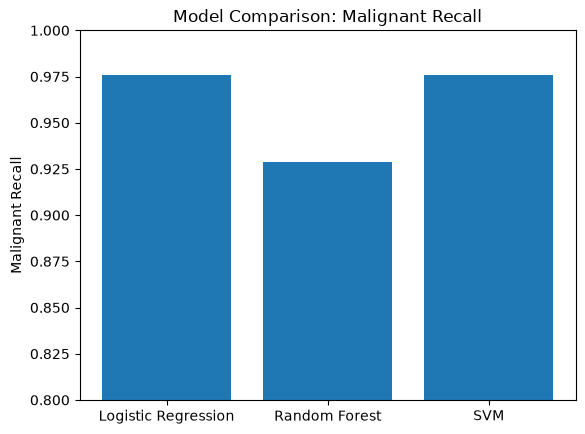

In [35]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest', 'SVM']
recalls = [0.976, 0.929, 0.976]

plt.bar(models, recalls)
plt.ylabel('Malignant Recall')
plt.title('Model Comparison: Malignant Recall')
plt.ylim(0.8, 1.0)
plt.show()

In [36]:
report_lr = classification_report(y_test, y_pred, target_names=data.target_names, output_dict=True)
report_rf = classification_report(y_test, rf_pred, target_names=data.target_names, output_dict=True)
report_svm = classification_report(y_test, svm_pred, target_names=data.target_names, output_dict=True)

In [37]:
recalls = [
    report_lr['malignant']['recall'],
    report_rf['malignant']['recall'],
    report_svm['malignant']['recall']
]
recalls

[0.9761904761904762, 0.9285714285714286, 0.9761904761904762]

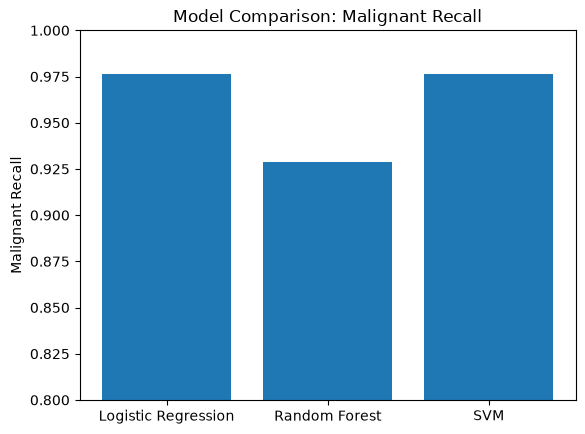

In [38]:
plt.bar(models, recalls)
plt.ylabel('Malignant Recall')
plt.title('Model Comparison: Malignant Recall')
plt.ylim(0.8, 1.0)
plt.savefig('../results/model_comparison.png')
plt.show()